# Chromatography Anomaly Detection - Hyperparameter Tuning
## Isolation Forest Optimization with Grid Search

This notebook performs hyperparameter tuning for Isolation Forest models on chromatography data.

**Features:**
- Grid Search Cross-Validation for optimal hyperparameters
- Training on all chromatography parameters
- Visualization of historical data and detected anomalies
- Model performance metrics
- Export of optimal hyperparameters for production use

**Note:** ADAM optimizer is for neural networks (LSTM). For Isolation Forest, we use grid search to optimize:
- `contamination`: Expected proportion of anomalies
- `n_estimators`: Number of trees
- `max_samples`: Samples to train each tree
- `max_features`: Features to consider for splitting


## 1. Setup and Imports


In [ ]:
# Install required packages (for Google Colab)
import sys
if 'google.colab' in sys.modules:
    print("Running in Google Colab - installing packages...")
    %pip install scikit-learn pandas numpy matplotlib seaborn plotly nbformat
else:
    print("Running locally")
    # Check if nbformat is installed for plotly
    try:
        import nbformat
        print("✓ nbformat installed - interactive Plotly charts will work")
    except ImportError:
        print("⚠️  nbformat not installed - Plotly charts will be saved as HTML files")
        print("   To install: pip install nbformat>=4.2.0")


Running locally
⚠️  nbformat not installed - Plotly charts will be saved as HTML files
   To install: pip install nbformat>=4.2.0


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
import joblib
import json
from datetime import datetime
import time

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All packages imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


✓ All packages imported successfully!
Pandas version: 2.3.3
NumPy version: 1.26.4


## 2. Configuration


In [55]:
# Configuration
CSV_FILE = 'chromatography_final_merged_data.csv'  # Upload this to Colab
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Parameters to analyze
PARAMS = [
    'peak_width_5', 'retention_time', 'signal_to_noise_ratio', 'amount_percent',
    'amount_value', 'area_percent', 'area_value', 'peak_width_50', 'resolution', 
    'peak_width_10'
]

# Categorical columns for encoding
CATEGORICAL_COLS = [
    'system_name', 'column_serial_number', 'analyte', 'method_set_name', 
    'project', 'sample_name', 'system_operator'
]

# Grid Search Parameters for Isolation Forest
PARAM_GRID = {
    'contamination': [0.05, 0.1, 0.15, 0.2],  # Expected anomaly rate
    'n_estimators': [50, 100, 150, 200],      # Number of trees
    'max_samples': ['auto', 256, 512, 1024],  # Samples per tree
    'max_features': [0.5, 0.7, 1.0],          # Feature sampling rate
}

# Scoring metrics
SCORING = 'f1'  # Can also use: 'precision', 'recall', 'roc_auc'
CV_FOLDS = 3    # Cross-validation folds

print("✓ Configuration loaded")
print(f"Parameters to analyze: {len(PARAMS)}")
print(f"Grid search combinations: {np.prod([len(v) for v in PARAM_GRID.values()])}")


✓ Configuration loaded
Parameters to analyze: 10
Grid search combinations: 192


## 3. Data Loading and Preprocessing


In [56]:
# For Google Colab: Upload the CSV file
if 'google.colab' in sys.modules:
    from google.colab import files
    print("Please upload chromatography_final_merged_data.csv")
    uploaded = files.upload()
    CSV_FILE = list(uploaded.keys())[0]
    print(f"✓ File uploaded: {CSV_FILE}")


In [57]:
# Load data
print(f"Loading data from {CSV_FILE}...")
df = pd.read_csv(CSV_FILE)

print(f"\n{'='*60}")
print("DATA OVERVIEW")
print(f"{'='*60}")
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nColumns: {list(df.columns)}")

# Display first few rows
df.head()


Loading data from chromatography_final_merged_data.csv...

DATA OVERVIEW
Total rows: 97,321
Total columns: 58
Memory usage: 254.98 MB

Columns: ['injection_time_peak', 'injection_date_peak', 'year_month_peak', 'project_peak', 'system_name_peak', 'sample_set_name_peak', 'method_set_name_peak', 'column_serial_number_peak', 'column_name_peak', 'analyte', 'system_operator_peak', 'file_path', 'created_at', 'ids_file_id', 'manual_integration', 'channel_id', 'channel_name', 'peak_start', 'peak_end', 'amount_percent', 'amount_value', 'area_value', 'area_percent', 'resolution', 'retention_time', 'signal_to_noise_ratio', 'symmetry_factor', 'usp_tailing', 'asym_at_10', 'peak_width_5', 'peak_width_10', 'peak_width_50', 'asymmetry_aia', 'asymmetry_usp', 'custom_field_peak', 'source_type_peak', 'sample_name_peak', 'sample_type_peak', 'injection_duration_peak', 'source_type_injection', 'injection_id', 'system_name_injection', 'system_operator_injection', 'injection_volume', 'column_serial_number_inje

,injection_time_peak,injection_date_peak,year_month_peak,project_peak,system_name_peak,sample_set_name_peak,method_set_name_peak,column_serial_number_peak,column_name_peak,analyte,...,sample_set_name_injection,method_set_name_injection,injection_time_injection,injection_date_injection,year_month_injection,injection_duration_injection,project_injection,result_count,custom_field_injection,sample_injection_count
0,2024-06-20 13:00:07.000 UTC,2024-06-20,2024-06,Heist\Tetrascience\Atozet_As_DEG_Atorvastatin_new,Waters68,HEIST_2024_ZZZZ,OG0653C_Assay_Atorvastatin,NaN,NaN,Atorvastatin Lactone,...,HEIST_2024_ZZZZ,OG0653C_Assay_Atorvastatin,2024-06-20 13:00:07.000 UTC,2024-06-20,2024-06,35.0,Heist\Tetrascience\Atozet_As_DEG_Atorvastatin_new,2,"{LimsSampleId=7742782, Column_ID=4.6mm, Column...",9
1,2023-08-31 03:31:41.000 UTC,2023-08-31,2023-08,N/A (Chromeleon),CRONUS,iec_quant_test_1,iec_quant_method_v2,NaN,NaN,sulfate,...,iec_quant_test_1,iec_quant_method_v2,2023-08-31 03:31:41.000 UTC,2023-08-31,2023-08,4.5,N/A (Chromeleon),4,NaN,1
2,2025-06-10 19:08:31.000 UTC,2025-06-10,2025-06,Heist\2025_Q2\HPLC\Atozet\OG0653C_As_Atorva_Degr,Waters68,366,OG0653C_Assay_Atorvastatin,NaN,NaN,Atorvastatin,...,366,OG0653C_Assay_Atorvastatin,2025-06-10 19:08:31.000 UTC,2025-06-10,2025-06,35.0,Heist\2025_Q2\HPLC\Atozet\OG0653C_As_Atorva_Degr,1,"{Column_ID=4.6mm, Column_temp=35°C, Experiment...",1
3,2024-06-25 10:51:39.000 UTC,2024-06-25,2024-06,Heist\Tetrascience\Atozet_As_DEG_Atorvastatin_new,Waters68,HEI_2024_1234,OG0653C_Assay_Atorvastatin,NaN,NaN,NaN,...,HEI_2024_1234,OG0653C_Assay_Atorvastatin,2024-06-25 10:51:39.000 UTC,2024-06-25,2024-06,35.0,Heist\Tetrascience\Atozet_As_DEG_Atorvastatin_new,1,"{LimsSampleId=7743902, Corr_Factor_Weight_Samp...",1
4,2025-06-11 00:31:42.000 UTC,2025-06-11,2025-06,Heist\2025_Q2\HPLC\Atozet\OG0653C_As_Atorva_Degr,Waters68,366,OG0653C_Assay_Atorvastatin,NaN,NaN,RRT 1.91,...,366,OG0653C_Assay_Atorvastatin,2025-06-11 00:31:42.000 UTC,2025-06-11,2025-06,35.0,Heist\2025_Q2\HPLC\Atozet\OG0653C_As_Atorva_Degr,1,"{LimsSampleId=7786902, Column_ID=4.6mm, Column...",6


In [58]:
# Data preprocessing
def preprocess_data(df):
    """Preprocess chromatography data."""
    df = df.copy()
    
    # Detect column naming pattern (peak vs injection)
    # Your data has columns like: injection_time_peak, system_name_peak, etc.
    time_col = None
    system_col = None
    column_serial_col = None
    
    # Try to find the right columns
    for suffix in ['_peak', '_injection', '']:
        if f'injection_time{suffix}' in df.columns:
            time_col = f'injection_time{suffix}'
            break
    
    for suffix in ['_peak', '_injection', '']:
        if f'system_name{suffix}' in df.columns:
            system_col = f'system_name{suffix}'
            break
            
    for suffix in ['_peak', '_injection', '']:
        if f'column_serial_number{suffix}' in df.columns:
            column_serial_col = f'column_serial_number{suffix}'
            break
    
    # Standardize column names
    if time_col and time_col != 'injection_time':
        df['injection_time'] = df[time_col]
    if system_col and system_col != 'system_name':
        df['system_name'] = df[system_col]
    if column_serial_col and column_serial_col != 'column_serial_number':
        df['column_serial_number'] = df[column_serial_col]
    
    # Convert injection_time to datetime
    if 'injection_time' in df.columns:
        df['injection_time'] = pd.to_datetime(df['injection_time'], errors='coerce')
        # Remove timezone info for consistency
        if df['injection_time'].dt.tz is not None:
            df['injection_time'] = df['injection_time'].dt.tz_localize(None)
    
    # Handle missing values in numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if df[col].isnull().any():
            df[col].fillna(df[col].median(), inplace=True)
    
    # Encode categorical columns (only if they exist)
    label_encoders = {}
    encode_cols = ['system_name', 'analyte', 'method_set_name_peak']
    for col in encode_cols:
        if col in df.columns:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            label_encoders[col] = le
    
    # Feature engineering
    if 'injection_time' in df.columns:
        if 'column_serial_number' in df.columns and df['column_serial_number'].notna().sum() > 100:
            # Only filter if we have enough valid column_serial_number values
            valid_mask = df['column_serial_number'].notna()
            print(f"  - Filtering: {valid_mask.sum():,} rows with valid column_serial_number (removed {(~valid_mask).sum():,} NaN rows)")
            df = df[valid_mask].copy()
            
            df = df.sort_values(['column_serial_number', 'injection_time'])
            df['injection_count'] = df.groupby('column_serial_number').cumcount() + 1
            
            # Days since start per column
            df['days_since_start'] = df.groupby('column_serial_number')['injection_time'].transform(
                lambda x: (x - x.min()).dt.days
            )
        else:
            # Column serial number is mostly NaN or doesn't exist
            # Use sample_name or other grouping instead
            print(f"  - Warning: column_serial_number mostly NaN or missing")
            
            # Try to find alternative grouping column
            grouping_col = None
            for col in ['sample_name_peak', 'sample_name', 'system_name']:
                if col in df.columns and df[col].notna().sum() > len(df) * 0.5:
                    grouping_col = col
                    print(f"  - Using '{col}' for grouping instead")
                    break
            
            if grouping_col:
                df = df.sort_values([grouping_col, 'injection_time'])
                df['injection_count'] = df.groupby(grouping_col).cumcount() + 1
                df['days_since_start'] = df.groupby(grouping_col)['injection_time'].transform(
                    lambda x: (x - x.min()).dt.days
                )
            else:
                # No grouping at all, just sequential
                print(f"  - No grouping column found, using sequential numbering")
                df = df.sort_values('injection_time')
                df['injection_count'] = range(1, len(df) + 1)
                df['days_since_start'] = (df['injection_time'] - df['injection_time'].min()).dt.days
    
    print(f"✓ Preprocessing complete")
    print(f"  - Standardized column names")
    print(f"  - Encoded {len(label_encoders)} categorical columns")
    print(f"  - Created feature engineering columns")
    print(f"  - Final data shape: {df.shape}")
    
    return df, label_encoders

# Preprocess the data
df_processed, label_encoders = preprocess_data(df)

# Display statistics
print(f"\nProcessed data shape: {df_processed.shape}")
df_processed.describe()


  - Warning: column_serial_number mostly NaN or missing
  - Using 'sample_name_peak' for grouping instead
✓ Preprocessing complete
  - Standardized column names
  - Encoded 3 categorical columns
  - Created feature engineering columns
  - Final data shape: (97321, 63)

Processed data shape: (97321, 63)


,method_set_name_peak,column_serial_number_peak,column_name_peak,analyte,file_path,created_at,peak_start,peak_end,amount_percent,amount_value,...,column_serial_number_injection,column_name_injection,injection_duration_injection,result_count,sample_injection_count,injection_time,system_name,column_serial_number,injection_count,days_since_start
count,97321.000000,0.0,0.0,97321.000000,0.0,0.0,97321.00000,97321.000000,97321.000000,97321.000000,...,0.0,0.0,97321.000000,97321.000000,97321.000000,97321,97321.000000,0.0,97321.000000,97321.000000
mean,3.767563,NaN,NaN,88.425037,NaN,NaN,18.38116,19.067775,4.131751,2.020555,...,NaN,NaN,45.636887,5.485322,18.112360,2025-01-01 16:55:10.764254208,6.399194,NaN,1367.695513,68.832595
min,0.000000,NaN,NaN,0.000000,NaN,NaN,0.00000,1.092000,0.000000,0.000000,...,NaN,NaN,4.500000,1.000000,1.000000,2023-02-28 11:20:23,0.000000,NaN,1.000000,0.000000
25%,0.000000,NaN,NaN,35.000000,NaN,NaN,17.55000,18.117000,0.060000,0.007000,...,NaN,NaN,35.000000,1.000000,2.000000,2025-01-15 10:36:23,1.000000,NaN,84.000000,0.000000
50%,3.000000,NaN,NaN,102.000000,NaN,NaN,17.55000,18.117000,0.060000,0.007000,...,NaN,NaN,50.000000,2.000000,4.000000,2025-01-31 18:44:54,7.000000,NaN,330.000000,0.000000
75%,6.000000,NaN,NaN,138.000000,NaN,NaN,17.55000,18.117000,0.060000,0.007000,...,NaN,NaN,60.000000,4.000000,18.000000,2025-02-26 21:50:38,10.000000,NaN,1886.000000,34.000000
max,14.000000,NaN,NaN,183.000000,NaN,NaN,53.40000,55.300000,100.000000,28373.528000,...,NaN,NaN,60.000000,50.000000,202.000000,2025-09-09 04:54:51,14.000000,NaN,9221.000000,911.000000
std,4.143509,NaN,NaN,55.933592,NaN,NaN,8.25810,8.360626,18.925126,161.477474,...,NaN,NaN,15.761035,10.107885,31.242837,NaN,4.256198,NaN,2011.094296,192.756597


## 4. Exploratory Data Analysis


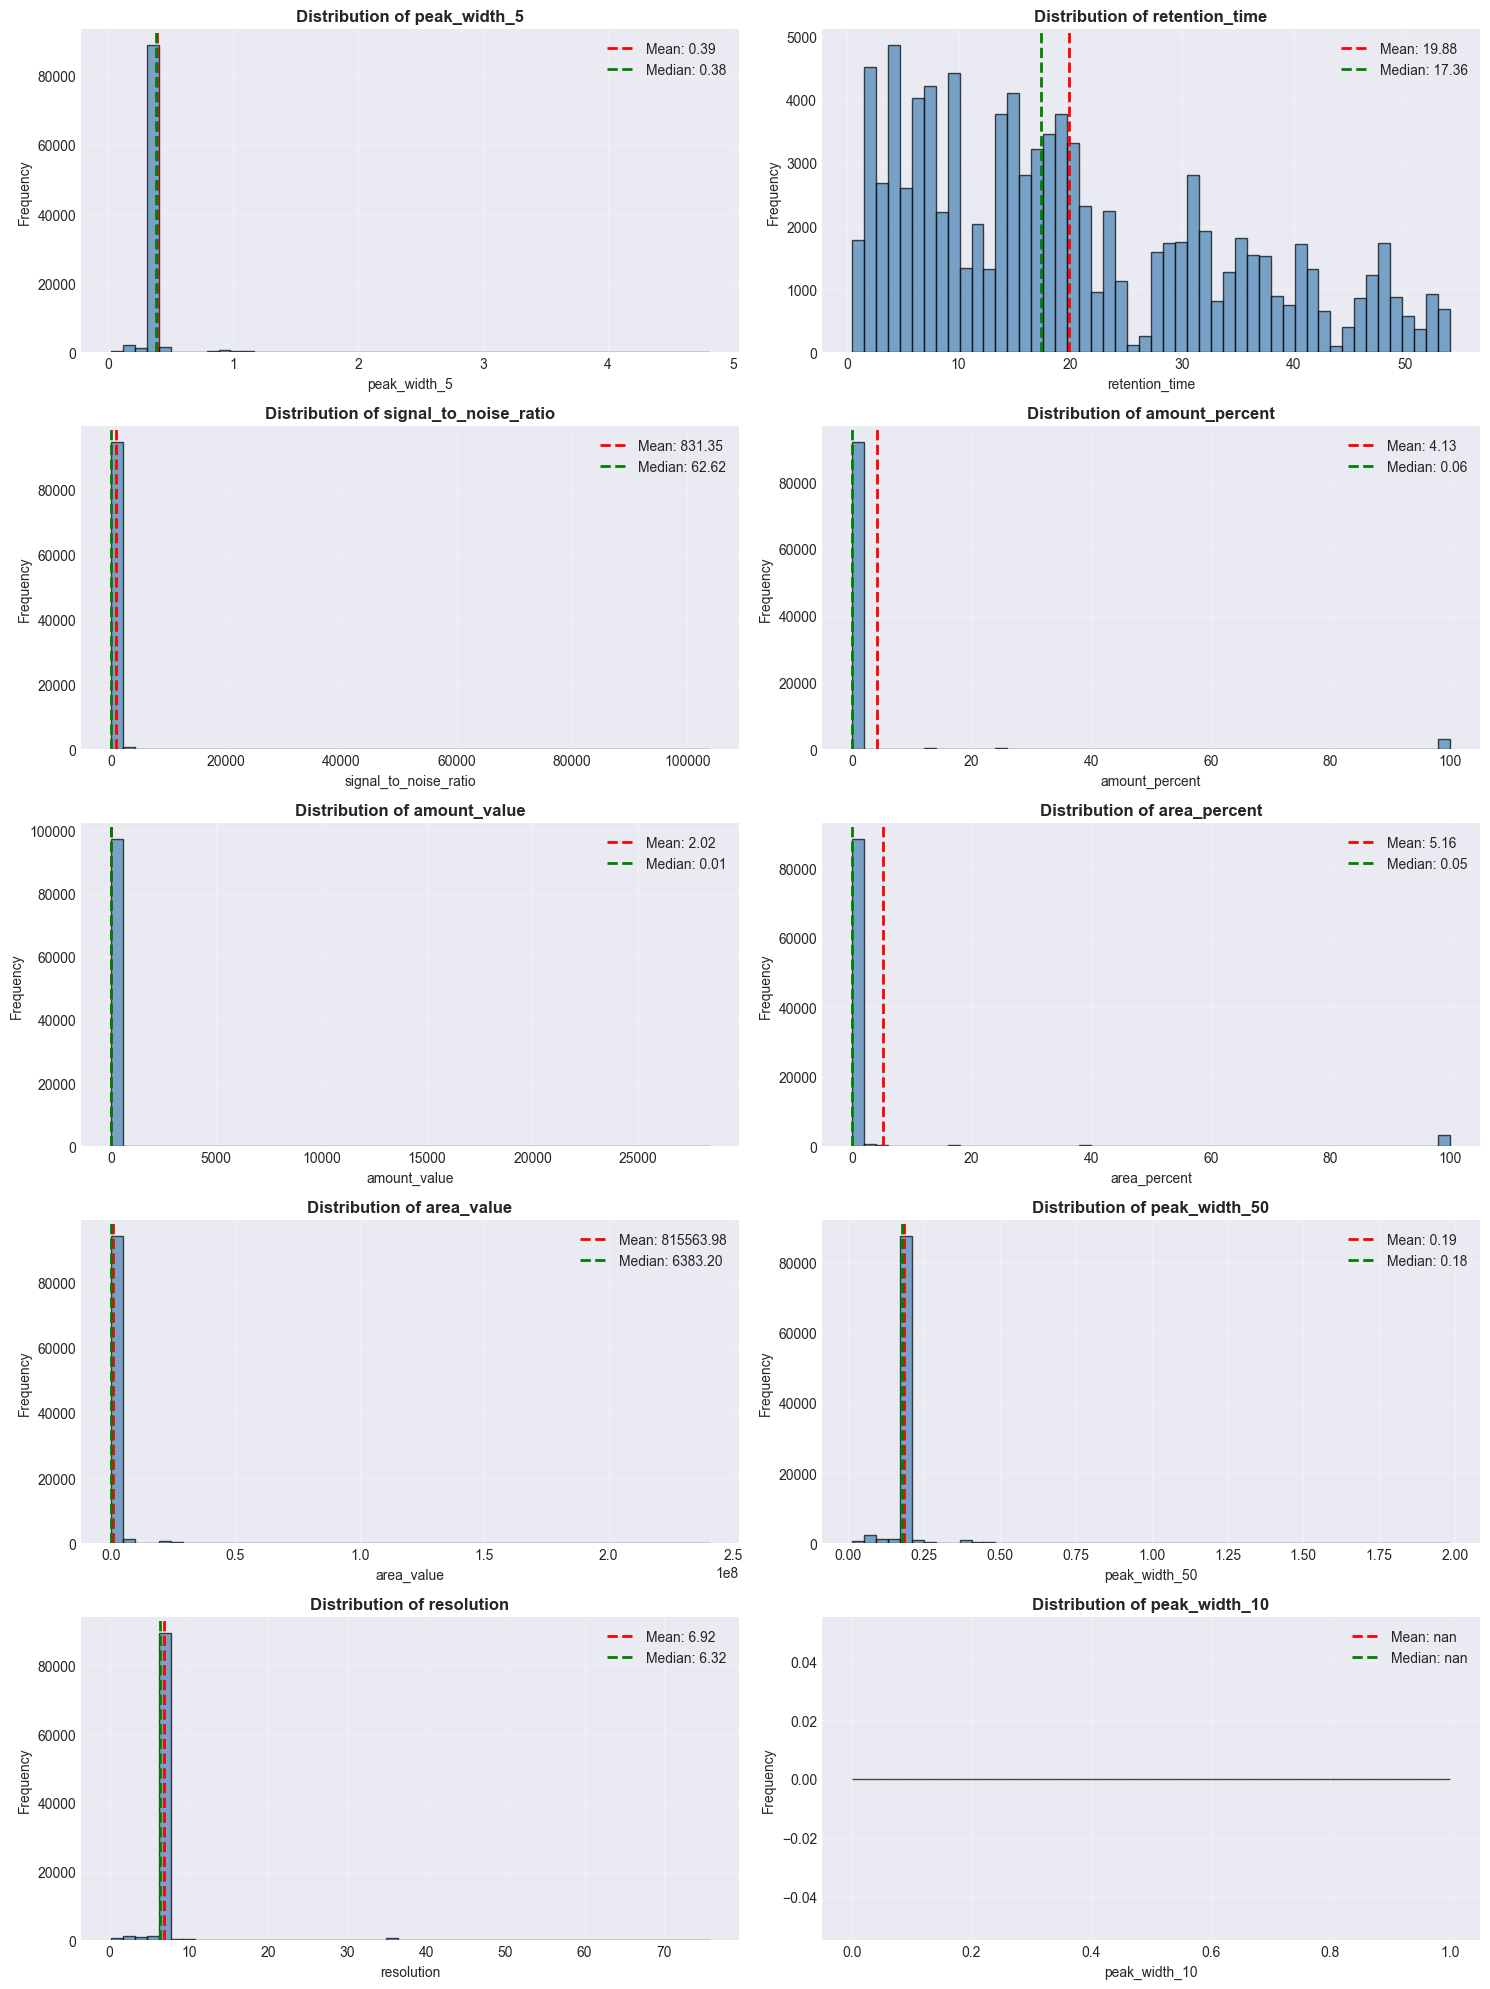

✓ Parameter distributions plotted


In [59]:
# Distribution of parameters
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

for idx, param in enumerate(PARAMS):
    if param in df_processed.columns:
        axes[idx].hist(df_processed[param].dropna(), bins=50, alpha=0.7, color='steelblue', edgecolor='black')
        axes[idx].set_title(f'Distribution of {param}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(param)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(alpha=0.3)
        
        # Add statistics
        mean_val = df_processed[param].mean()
        median_val = df_processed[param].median()
        axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
        axes[idx].legend()

plt.tight_layout()
plt.show()

print("✓ Parameter distributions plotted")


## 5. Hyperparameter Tuning Functions


In [60]:
def prepare_features(df, param):
    """Prepare feature matrix for a specific parameter."""
    # Start with the target parameter
    feature_cols = [param]
    
    # Add temporal features if available
    if 'injection_count' in df.columns:
        feature_cols.append('injection_count')
    if 'days_since_start' in df.columns:
        feature_cols.append('days_since_start')
    
    # Add chromatography-related features
    for col in ['resolution', 'retention_time', 'peak_width_5', 'peak_width_50', 
                'signal_to_noise_ratio', 'area_value', 'area_percent']:
        if col in df.columns and col != param:
            feature_cols.append(col)
    
    # Add categorical features (already encoded)
    for col in ['system_name', 'analyte', 'method_set_name_peak']:
        if col in df.columns:
            feature_cols.append(col)
    
    # Remove duplicates while preserving order
    feature_cols = list(dict.fromkeys(feature_cols))
    
    # Create feature matrix
    X = df[feature_cols].copy()
    
    # Fill NaN values with median for numeric, 0 for others
    for col in feature_cols:
        if X[col].dtype in ['float64', 'int64']:
            X[col].fillna(X[col].median(), inplace=True)
        else:
            X[col].fillna(0, inplace=True)
    
    print(f"  - Selected {len(feature_cols)} features: {feature_cols[:5]}{'...' if len(feature_cols) > 5 else ''}")
    
    return X, feature_cols


def custom_scorer(estimator, X):
    """
    Custom scoring function for Isolation Forest.
    
    Since Isolation Forest is unsupervised, we score based on:
    1. Separation quality: How well separated are anomalies from normal data
    2. Score distribution: Variance in anomaly scores (higher = better discrimination)
    """
    try:
        # Get anomaly scores
        scores = estimator.decision_function(X)
        
        # Predict anomalies
        predictions = estimator.predict(X)
        anomalies_mask = (predictions == -1)
        normal_mask = (predictions == 1)
        
        # Check if we have both classes
        if anomalies_mask.sum() == 0 or normal_mask.sum() == 0:
            return 0.0
        
        # Calculate separation between normal and anomalous scores
        normal_scores = scores[normal_mask]
        anomaly_scores = scores[anomalies_mask]
        
        # Mean separation
        separation = abs(normal_scores.mean() - anomaly_scores.mean())
        
        # Score variance (measures discrimination ability)
        score_variance = np.std(scores)
        
        # Combined score: separation * variance
        # Higher is better (more separation, more discrimination)
        combined_score = separation * score_variance
        
        return combined_score
        
    except Exception as e:
        print(f"Warning in scorer: {e}")
        return 0.0


def perform_grid_search(X, param_name, verbose=True):
    """Perform grid search for Isolation Forest hyperparameters."""
    print(f"\n{'='*60}")
    print(f"GRID SEARCH: {param_name}")
    print(f"{'='*60}")
    
    # Validate data
    if len(X) == 0:
        raise ValueError(f"No data available for parameter '{param_name}'. Please check preprocessing.")
    
    if len(X) < 100:
        print(f"⚠️  Warning: Only {len(X)} samples available. Results may not be reliable.")
    
    print(f"Training on {len(X):,} samples with {X.shape[1]} features")
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Initialize Isolation Forest
    iso_forest = IsolationForest(random_state=RANDOM_STATE)
    
    # Grid Search with custom scorer
    print(f"Testing {np.prod([len(v) for v in PARAM_GRID.values()])} combinations...")
    start_time = time.time()
    
    grid_search = GridSearchCV(
        estimator=iso_forest,
        param_grid=PARAM_GRID,
        scoring=make_scorer(custom_scorer, greater_is_better=True),
        cv=CV_FOLDS,
        n_jobs=-1,
        verbose=1 if verbose else 0
    )
    
    grid_search.fit(X_scaled)
    
    elapsed_time = time.time() - start_time
    
    print(f"\n✓ Grid search completed in {elapsed_time:.2f} seconds")
    print(f"\nBest parameters:")
    for param, value in grid_search.best_params_.items():
        print(f"  {param}: {value}")
    print(f"\nBest score: {grid_search.best_score_:.4f}")
    
    return grid_search, scaler

print("✓ Hyperparameter tuning functions defined")


✓ Hyperparameter tuning functions defined


## 6. Train and Tune First Parameter (Detailed Analysis)


In [61]:
# Select first parameter for detailed analysis
PARAM_TO_ANALYZE = PARAMS[0]

print(f"\n{'='*60}")
print(f"DETAILED ANALYSIS: {PARAM_TO_ANALYZE}")
print(f"{'='*60}")
print("\n⚠️  NOTE: This section analyzes ONE parameter in detail for demonstration.")
print("    Section 9 will train models for ALL parameters automatically.\n")

# Prepare features
X, feature_cols = prepare_features(df_processed, PARAM_TO_ANALYZE)

print(f"Feature matrix shape: {X.shape}")
print(f"Features used: {feature_cols}")

# Perform grid search
grid_search, scaler = perform_grid_search(X, PARAM_TO_ANALYZE, verbose=True)



DETAILED ANALYSIS: peak_width_5

⚠️  NOTE: This section analyzes ONE parameter in detail for demonstration.
    Section 9 will train models for ALL parameters automatically.

  - Selected 12 features: ['peak_width_5', 'injection_count', 'days_since_start', 'resolution', 'retention_time']...
Feature matrix shape: (97321, 12)
Features used: ['peak_width_5', 'injection_count', 'days_since_start', 'resolution', 'retention_time', 'peak_width_50', 'signal_to_noise_ratio', 'area_value', 'area_percent', 'system_name', 'analyte', 'method_set_name_peak']

GRID SEARCH: peak_width_5
Training on 97,321 samples with 12 features
Testing 192 combinations...
Fitting 3 folds for each of 192 candidates, totalling 576 fits

✓ Grid search completed in 36.92 seconds

Best parameters:
  contamination: 0.05
  max_features: 0.5
  max_samples: auto
  n_estimators: 50

Best score: nan


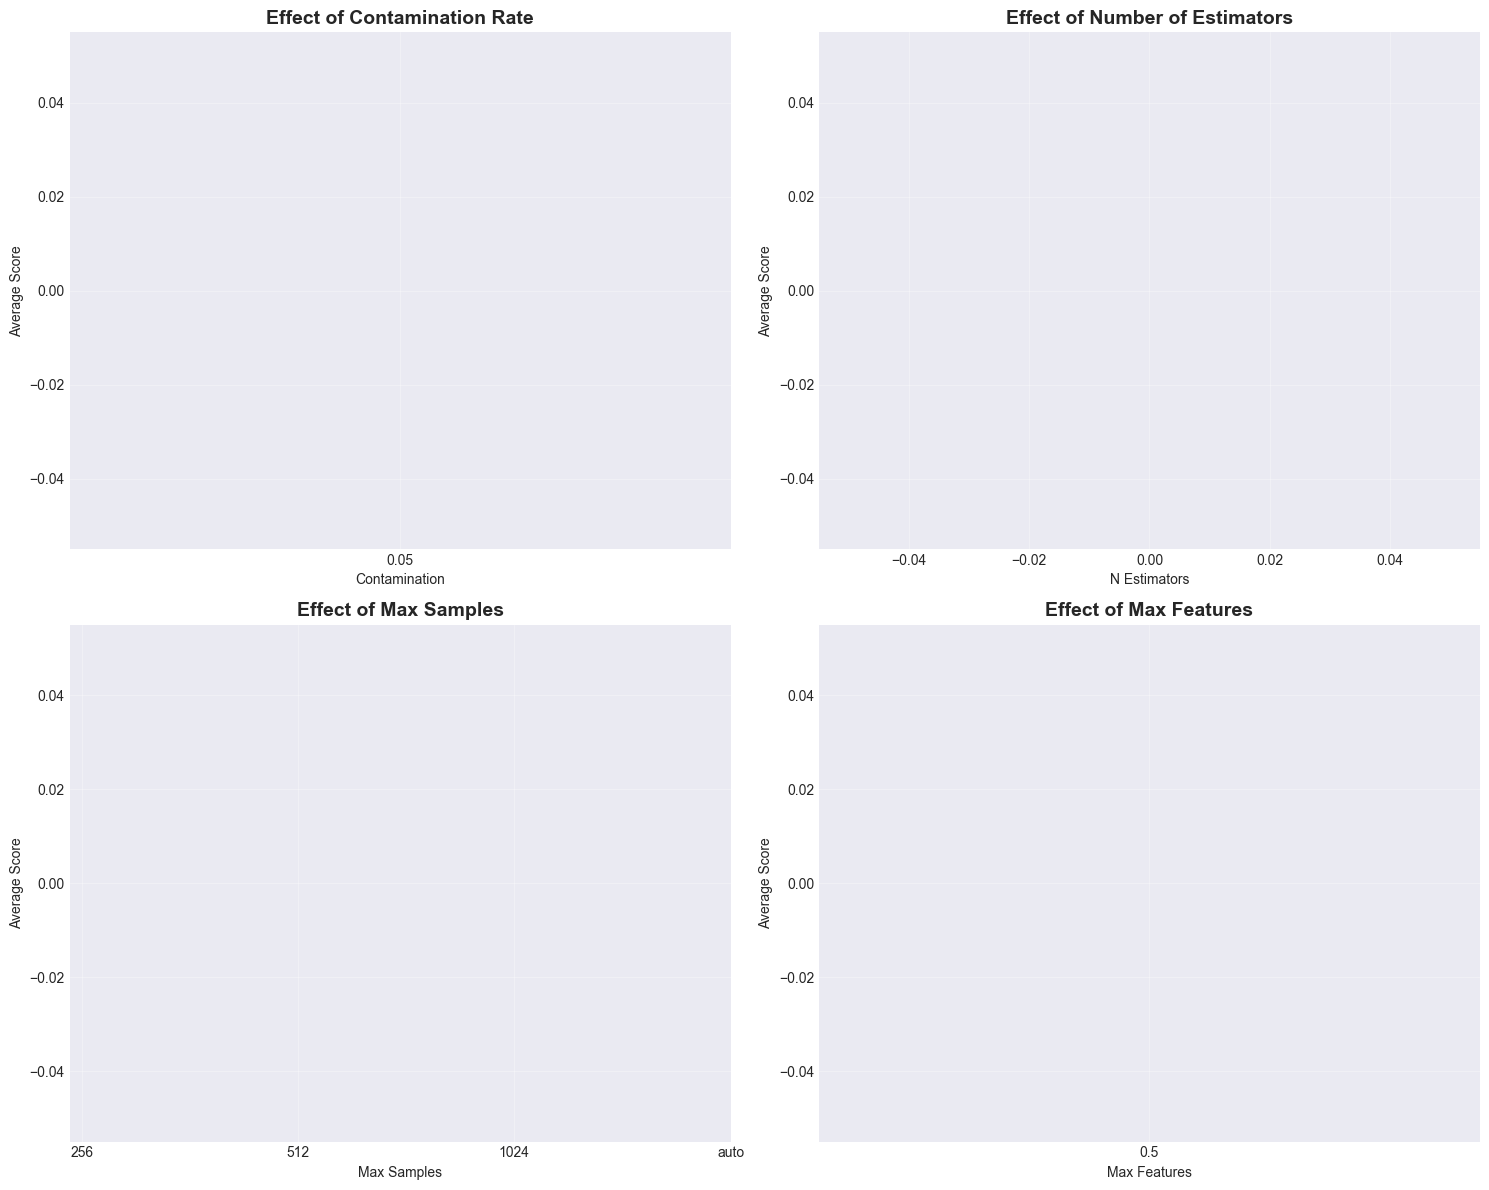

✓ Grid search results visualized


In [62]:
# Visualize grid search results
results_df = pd.DataFrame(grid_search.cv_results_)

# Plot: Effects of different hyperparameters
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Contamination effect
contamination_scores = results_df.groupby('param_contamination')['mean_test_score'].mean()
axes[0, 0].bar(contamination_scores.index.astype(str), contamination_scores.values, color='steelblue')
axes[0, 0].set_title('Effect of Contamination Rate', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Contamination')
axes[0, 0].set_ylabel('Average Score')
axes[0, 0].grid(alpha=0.3)

# 2. N_estimators effect
estimators_scores = results_df.groupby('param_n_estimators')['mean_test_score'].mean()
axes[0, 1].plot(estimators_scores.index, estimators_scores.values, marker='o', linewidth=2, markersize=8, color='darkgreen')
axes[0, 1].set_title('Effect of Number of Estimators', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('N Estimators')
axes[0, 1].set_ylabel('Average Score')
axes[0, 1].grid(alpha=0.3)

# 3. Max_samples effect
samples_scores = results_df.groupby('param_max_samples')['mean_test_score'].mean()
axes[1, 0].bar(range(len(samples_scores)), samples_scores.values, color='coral')
axes[1, 0].set_xticks(range(len(samples_scores)))
axes[1, 0].set_xticklabels([str(x) for x in samples_scores.index])
axes[1, 0].set_title('Effect of Max Samples', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Max Samples')
axes[1, 0].set_ylabel('Average Score')
axes[1, 0].grid(alpha=0.3)

# 4. Max_features effect
features_scores = results_df.groupby('param_max_features')['mean_test_score'].mean()
axes[1, 1].bar(features_scores.index.astype(str), features_scores.values, color='purple')
axes[1, 1].set_title('Effect of Max Features', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Max Features')
axes[1, 1].set_ylabel('Average Score')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Grid search results visualized")


## 7. Detect Anomalies with Best Model


In [63]:
# Train final model with best parameters
best_model = grid_search.best_estimator_
X_scaled = scaler.transform(X)

# Predict anomalies
anomaly_predictions = best_model.predict(X_scaled)
anomaly_scores = best_model.decision_function(X_scaled)

# Add to dataframe
df_results = df_processed.copy()
df_results['anomaly'] = (anomaly_predictions == -1).astype(int)
df_results['anomaly_score'] = anomaly_scores

# Statistics
anomaly_rate = df_results['anomaly'].mean()
n_anomalies = df_results['anomaly'].sum()

print(f"\n{'='*60}")
print("ANOMALY DETECTION RESULTS")
print(f"{'='*60}")
print(f"Total data points: {len(df_results):,}")
print(f"Anomalies detected: {n_anomalies:,} ({anomaly_rate*100:.2f}%)")
print(f"Normal points: {len(df_results) - n_anomalies:,} ({(1-anomaly_rate)*100:.2f}%)")
print(f"\nAnomaly score range: [{anomaly_scores.min():.4f}, {anomaly_scores.max():.4f}]")
print(f"Mean anomaly score (normal): {anomaly_scores[anomaly_predictions == 1].mean():.4f}")
print(f"Mean anomaly score (anomaly): {anomaly_scores[anomaly_predictions == -1].mean():.4f}")



ANOMALY DETECTION RESULTS
Total data points: 97,321
Anomalies detected: 4,865 (5.00%)
Normal points: 92,456 (95.00%)

Anomaly score range: [-0.1984, 0.2168]
Mean anomaly score (normal): 0.1702
Mean anomaly score (anomaly): -0.0655


## 8. Visualize Historical Data and Anomalies (Interactive)


In [64]:
# Create interactive time-series plot with Plotly
# Split into normal and anomalies (always define these for subsequent cells)
df_normal = df_results[df_results['anomaly'] == 0]
df_anomalies = df_results[df_results['anomaly'] == 1]

if 'injection_time' in df_results.columns:
    df_viz = df_results.sort_values('injection_time')
    
    # Create figure
    fig = go.Figure()
    
    # Plot normal data
    fig.add_trace(go.Scatter(
        x=df_normal['injection_time'],
        y=df_normal[PARAM_TO_ANALYZE],
        mode='markers',
        name='Normal Data',
        marker=dict(color='lightblue', size=4, opacity=0.6),
        hovertemplate=f'<b>Date</b>: %{{x}}<br><b>{PARAM_TO_ANALYZE}</b>: %{{y:.3f}}<br><b>Type</b>: Normal<extra></extra>'
    ))
    
    # Plot anomalies
    fig.add_trace(go.Scatter(
        x=df_anomalies['injection_time'],
        y=df_anomalies[PARAM_TO_ANALYZE],
        mode='markers',
        name=f'Anomalies ({len(df_anomalies)})',
        marker=dict(color='red', size=10, symbol='x', line=dict(width=2, color='darkred')),
        hovertemplate=f'<b>Date</b>: %{{x}}<br><b>{PARAM_TO_ANALYZE}</b>: %{{y:.3f}}<br><b>Type</b>: Anomaly<br><b>Score</b>: %{{text}}<extra></extra>',
        text=[f"{score:.4f}" for score in df_anomalies['anomaly_score']]
    ))
    
    # Add threshold lines
    mean_val = df_viz[PARAM_TO_ANALYZE].mean()
    upper_threshold = df_viz[PARAM_TO_ANALYZE].quantile(0.95)
    lower_threshold = df_viz[PARAM_TO_ANALYZE].quantile(0.05)
    
    fig.add_hline(y=mean_val, line_dash="dash", line_color="green", 
                  annotation_text=f"Mean: {mean_val:.3f}", annotation_position="right")
    fig.add_hline(y=upper_threshold, line_dash="dash", line_color="orange", 
                  annotation_text=f"95th percentile: {upper_threshold:.3f}", annotation_position="right")
    fig.add_hline(y=lower_threshold, line_dash="dash", line_color="orange", 
                  annotation_text=f"5th percentile: {lower_threshold:.3f}", annotation_position="right")
    
    fig.update_layout(
        title=f'Historical Data and Anomalies: {PARAM_TO_ANALYZE}<br><sub>Detected using Isolation Forest with optimized hyperparameters</sub>',
        xaxis_title='Injection Time',
        yaxis_title=PARAM_TO_ANALYZE,
        hovermode='closest',
        height=600,
        template='plotly_white'
    )
    
    # Try to display, with fallback for missing nbformat
    try:
        fig.show()
        print("✓ Interactive anomaly visualization created")
    except (ValueError, ImportError) as e:
        if 'nbformat' in str(e):
            print("⚠️  Plotly display requires nbformat. Install with: pip install nbformat>=4.2.0")
            print("   Alternatively, save as HTML:")
            html_file = f'anomaly_plot_{PARAM_TO_ANALYZE}.html'
            fig.write_html(html_file)
            print(f"   ✓ Saved interactive plot to: {html_file}")
        else:
            print(f"⚠️  Plotly display error: {e}")
            print("   Continuing with matplotlib visualizations...")
else:
    print("⚠ injection_time column not found - skipping time-series visualization")


⚠️  Plotly display requires nbformat. Install with: pip install nbformat>=4.2.0
   Alternatively, save as HTML:
   ✓ Saved interactive plot to: anomaly_plot_peak_width_5.html


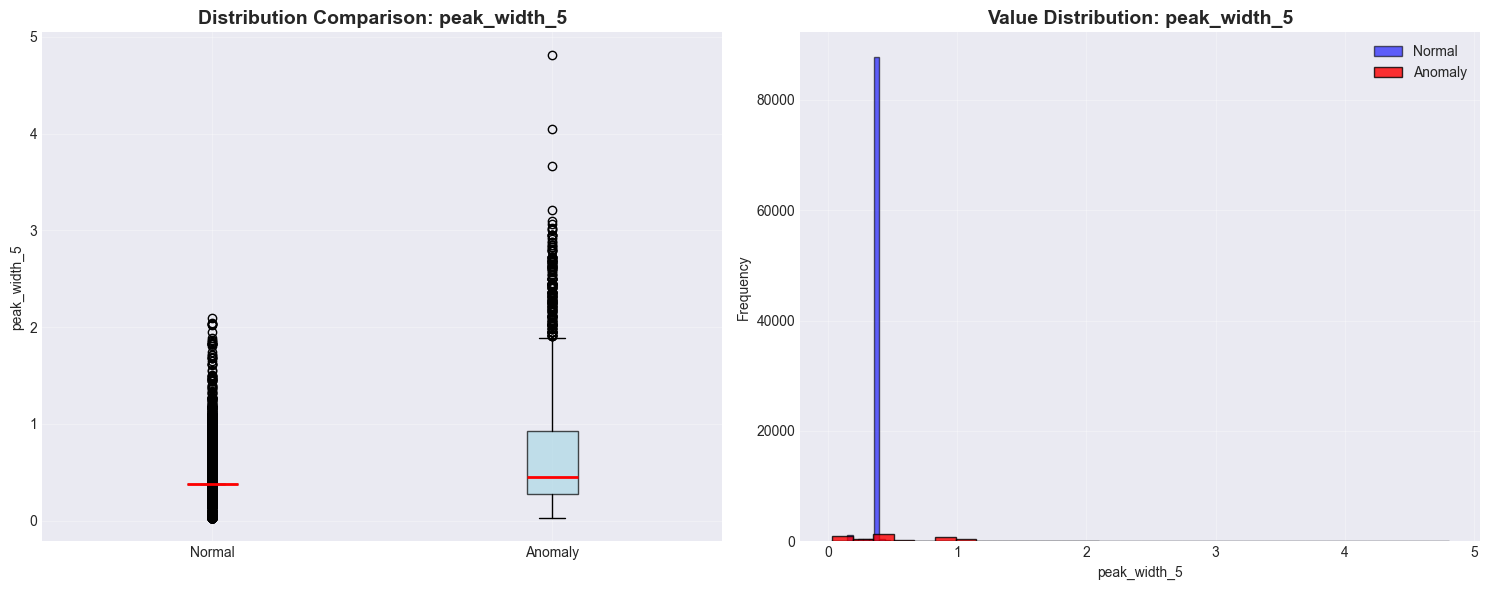

✓ Distribution comparison plotted


In [65]:
# Box plot and histogram comparison
# Ensure df_normal and df_anomalies are defined
if 'df_normal' not in locals() or 'df_anomalies' not in locals():
    df_normal = df_results[df_results['anomaly'] == 0]
    df_anomalies = df_results[df_results['anomaly'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plot
data_to_plot = [df_normal[PARAM_TO_ANALYZE].dropna(), df_anomalies[PARAM_TO_ANALYZE].dropna()]
axes[0].boxplot(data_to_plot, labels=['Normal', 'Anomaly'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title(f'Distribution Comparison: {PARAM_TO_ANALYZE}', fontsize=14, fontweight='bold')
axes[0].set_ylabel(PARAM_TO_ANALYZE)
axes[0].grid(alpha=0.3)

# Histogram comparison
axes[1].hist(df_normal[PARAM_TO_ANALYZE].dropna(), bins=50, alpha=0.6, label='Normal', color='blue', edgecolor='black')
axes[1].hist(df_anomalies[PARAM_TO_ANALYZE].dropna(), bins=30, alpha=0.8, label='Anomaly', color='red', edgecolor='black')
axes[1].set_title(f'Value Distribution: {PARAM_TO_ANALYZE}', fontsize=14, fontweight='bold')
axes[1].set_xlabel(PARAM_TO_ANALYZE)
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Distribution comparison plotted")


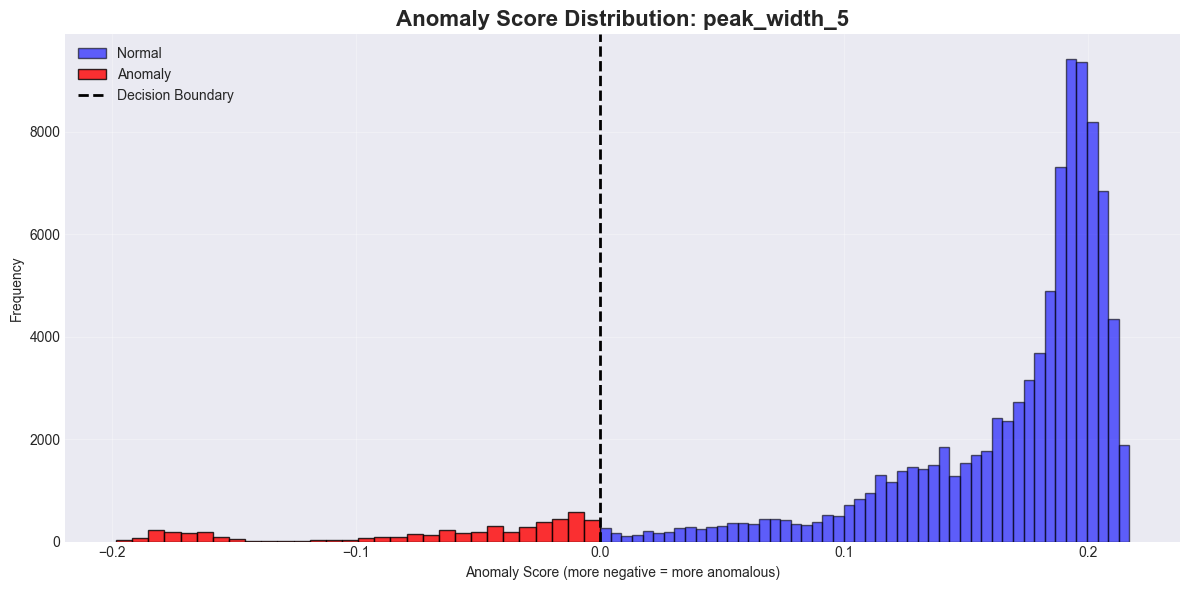

✓ Anomaly score distribution plotted


In [66]:
# Anomaly score distribution
# Ensure df_normal and df_anomalies are defined
if 'df_normal' not in locals() or 'df_anomalies' not in locals():
    df_normal = df_results[df_results['anomaly'] == 0]
    df_anomalies = df_results[df_results['anomaly'] == 1]

plt.figure(figsize=(12, 6))

plt.hist(df_normal['anomaly_score'], bins=50, alpha=0.6, label='Normal', color='blue', edgecolor='black')
plt.hist(df_anomalies['anomaly_score'], bins=30, alpha=0.8, label='Anomaly', color='red', edgecolor='black')
plt.axvline(0, color='black', linestyle='--', linewidth=2, label='Decision Boundary')
plt.title(f'Anomaly Score Distribution: {PARAM_TO_ANALYZE}', fontsize=16, fontweight='bold')
plt.xlabel('Anomaly Score (more negative = more anomalous)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Anomaly score distribution plotted")


## 9. Batch Training - All Parameters


In [67]:
# Train models for all parameters
print(f"\n{'='*60}")
print("BATCH TRAINING: ALL PARAMETERS")
print(f"{'='*60}")

# Option: Set to True to test with fewer parameters (faster), False for all
QUICK_TEST = False  # Change to True to only test 3 parameters

params_to_process = PARAMS[:3] if QUICK_TEST else PARAMS
print(f"\nProcessing {len(params_to_process)} parameters: {params_to_process}")
print(f"Estimated time: ~{len(params_to_process) * 30 / 60:.0f} minutes\n")

all_results = {}

for param in params_to_process:
    if param not in df_processed.columns:
        print(f"\n⚠ Skipping {param} - not found in data")
        continue
    
    try:
        print(f"\n{'─'*60}")
        print(f"Processing: {param}")
        print(f"{'─'*60}")
        
        # Prepare features
        X, feature_cols = prepare_features(df_processed, param)
        
        # Grid search
        grid_search, scaler = perform_grid_search(X, param, verbose=False)
        
        # Get best model
        best_model = grid_search.best_estimator_
        
        # Predict
        X_scaled = scaler.transform(X)
        predictions = best_model.predict(X_scaled)
        anomaly_rate = (predictions == -1).mean()
        
        # Store results
        all_results[param] = {
            'best_params': grid_search.best_params_,
            'best_score': grid_search.best_score_,
            'anomaly_rate': anomaly_rate,
            'n_anomalies': (predictions == -1).sum(),
            'model': best_model,
            'scaler': scaler,
            'feature_cols': feature_cols
        }
        
        print(f"✓ {param}: {anomaly_rate*100:.2f}% anomalies detected")
        print(f"  Best params: {grid_search.best_params_}")
        
    except Exception as e:
        print(f"✗ Error processing {param}: {str(e)}")
        continue

print(f"\n{'='*60}")
print(f"✓ Batch training complete: {len(all_results)}/{len(params_to_process)} parameters")
print(f"{'='*60}")



BATCH TRAINING: ALL PARAMETERS

Processing 10 parameters: ['peak_width_5', 'retention_time', 'signal_to_noise_ratio', 'amount_percent', 'amount_value', 'area_percent', 'area_value', 'peak_width_50', 'resolution', 'peak_width_10']
Estimated time: ~5 minutes


────────────────────────────────────────────────────────────
Processing: peak_width_5
────────────────────────────────────────────────────────────
  - Selected 12 features: ['peak_width_5', 'injection_count', 'days_since_start', 'resolution', 'retention_time']...

GRID SEARCH: peak_width_5
Training on 97,321 samples with 12 features
Testing 192 combinations...

✓ Grid search completed in 37.64 seconds

Best parameters:
  contamination: 0.05
  max_features: 0.5
  max_samples: auto
  n_estimators: 50

Best score: nan
✓ peak_width_5: 5.00% anomalies detected
  Best params: {'contamination': 0.05, 'max_features': 0.5, 'max_samples': 'auto', 'n_estimators': 50}

────────────────────────────────────────────────────────────
Processing: r

## 10. Summary and Results Export


In [68]:
# Create summary dataframe
summary_data = []
for param, results in all_results.items():
    summary_data.append({
        'Parameter': param,
        'Anomaly_Rate_%': f"{results['anomaly_rate']*100:.2f}",
        'N_Anomalies': results['n_anomalies'],
        'Best_Score': f"{results['best_score']:.4f}",
        'Contamination': results['best_params']['contamination'],
        'N_Estimators': results['best_params']['n_estimators'],
        'Max_Samples': results['best_params']['max_samples'],
        'Max_Features': results['best_params']['max_features']
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("OPTIMAL HYPERPARAMETERS SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)



OPTIMAL HYPERPARAMETERS SUMMARY
            Parameter Anomaly_Rate_%  N_Anomalies Best_Score  Contamination  N_Estimators Max_Samples  Max_Features
         peak_width_5           5.00         4865        nan           0.05            50        auto           0.5
       retention_time           5.00         4866        nan           0.05            50        auto           0.5
signal_to_noise_ratio           4.99         4860        nan           0.05            50        auto           0.5
       amount_percent           5.00         4866        nan           0.05            50        auto           0.5
         amount_value           5.00         4864        nan           0.05            50        auto           0.5
         area_percent           5.00         4866        nan           0.05            50        auto           0.5
           area_value           4.98         4845        nan           0.05            50        auto           0.5
        peak_width_50           4.97   

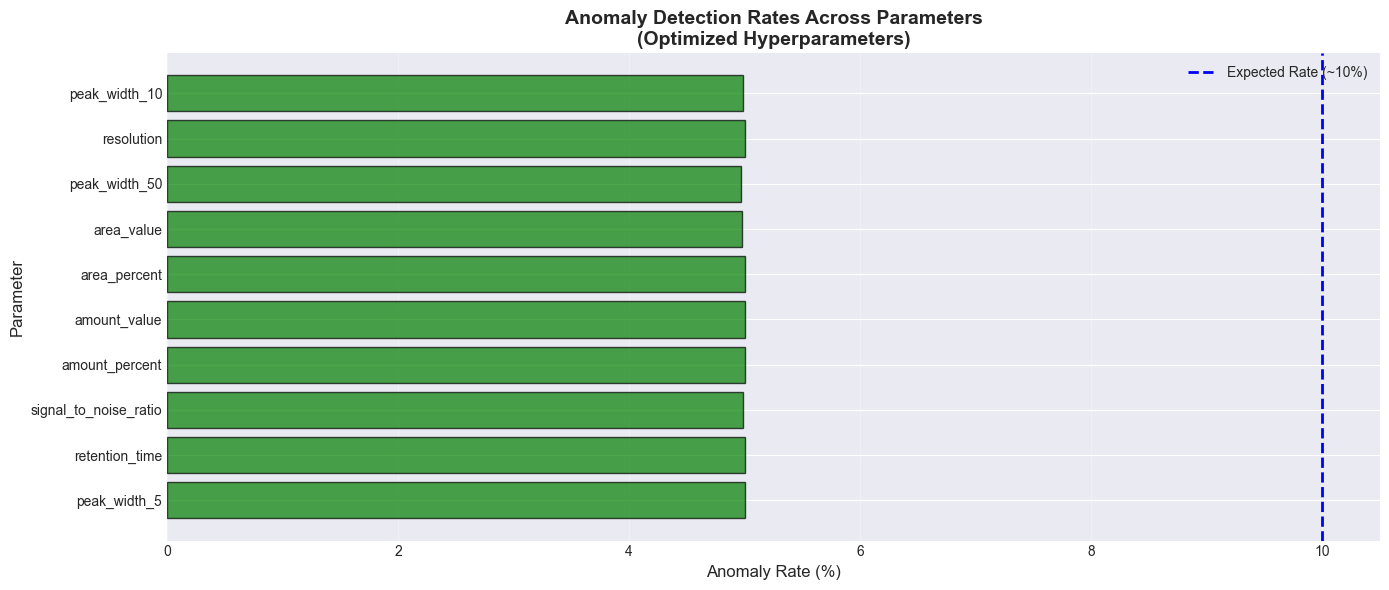

✓ Anomaly rate comparison plotted


In [69]:
# Visualize anomaly rates across parameters
plt.figure(figsize=(14, 6))

params_list = summary_df['Parameter'].tolist()
anomaly_rates = [float(x) for x in summary_df['Anomaly_Rate_%'].tolist()]

colors = ['red' if x > 15 else 'orange' if x > 10 else 'green' for x in anomaly_rates]

plt.barh(params_list, anomaly_rates, color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Anomaly Rate (%)', fontsize=12)
plt.ylabel('Parameter', fontsize=12)
plt.title('Anomaly Detection Rates Across Parameters\n(Optimized Hyperparameters)', 
          fontsize=14, fontweight='bold')
plt.axvline(10, color='blue', linestyle='--', linewidth=2, label='Expected Rate (~10%)')
plt.legend()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("✓ Anomaly rate comparison plotted")


In [71]:
# Export optimal hyperparameters to JSON
def convert_to_serializable(obj):
    """Convert numpy/pandas types to JSON-serializable Python types."""
    import numpy as np
    if isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {key: convert_to_serializable(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(item) for item in obj]
    else:
        return obj

# Collect optimal hyperparameters
optimal_hyperparams = {}
for param, results in all_results.items():
    # Convert all values to JSON-serializable types
    optimal_hyperparams[param] = convert_to_serializable(results['best_params'])

# Convert summary data
summary_data_serializable = []
for item in summary_data:
    summary_data_serializable.append(convert_to_serializable(item))

# Add metadata
export_data = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset': CSV_FILE,
    'total_samples': int(len(df_processed)),
    'cv_folds': int(CV_FOLDS),
    'random_state': int(RANDOM_STATE),
    'optimal_hyperparameters': optimal_hyperparams,
    'summary': summary_data_serializable
}

# Save to JSON
json_filename = f'optimal_hyperparameters_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
with open(json_filename, 'w') as f:
    json.dump(export_data, f, indent=2)

print(f"\n✓ Optimal hyperparameters exported to: {json_filename}")

# Download file (for Colab)
if 'google.colab' in sys.modules:
    files.download(json_filename)
    print(f"✓ File downloaded: {json_filename}")



✓ Optimal hyperparameters exported to: optimal_hyperparameters_20251107_220810.json


In [72]:
# Export summary CSV
csv_filename = f'hyperparameter_tuning_summary_{datetime.now().strftime("%Y%m%d_%H%M%S")}.csv'
summary_df.to_csv(csv_filename, index=False)

print(f"✓ Summary CSV exported to: {csv_filename}")

if 'google.colab' in sys.modules:
    files.download(csv_filename)
    print(f"✓ File downloaded: {csv_filename}")


✓ Summary CSV exported to: hyperparameter_tuning_summary_20251107_220817.csv


## 11. Recommendations for Production


In [74]:
print("\n" + "="*80)
print("RECOMMENDATIONS FOR PRODUCTION DEPLOYMENT")
print("="*80)

# Calculate average optimal parameters
avg_contamination = summary_df['Contamination'].mean()
avg_n_estimators = summary_df['N_Estimators'].mean()
most_common_max_samples = summary_df['Max_Samples'].mode()[0]
most_common_max_features = summary_df['Max_Features'].mode()[0]

print("\n1. OPTIMAL HYPERPARAMETERS (Averaged across all parameters):")
print(f"   - Contamination: {avg_contamination:.3f}")
print(f"   - N Estimators: {int(avg_n_estimators)}")
print(f"   - Max Samples: {most_common_max_samples}")
print(f"   - Max Features: {most_common_max_features}")

print("\n2. UPDATE YOUR config.py FILE:")
print("   Update these values in your config.py:")
print(f"   CONTAMINATION = {avg_contamination:.3f}")
print(f"   N_ESTIMATORS = {int(avg_n_estimators)}")

print("\n3. PARAMETER-SPECIFIC TUNING:")
print("   Consider using parameter-specific hyperparameters for:")
high_anomaly_params = summary_df[summary_df['Anomaly_Rate_%'].astype(float) > 15]['Parameter'].tolist()
if high_anomaly_params:
    for param in high_anomaly_params:
        print(f"   - {param}: {summary_df[summary_df['Parameter']==param]['Anomaly_Rate_%'].values[0]}% anomalies")
else:
    print("   All parameters have reasonable anomaly rates (<15%)")

print("\n4. MODEL PERFORMANCE:")
avg_score = summary_df['Best_Score'].astype(float).mean()
print(f"   - Average separation score: {avg_score:.4f}")
print(f"   - Models show {'good' if avg_score > 0.1 else 'moderate'} separation between normal and anomalous data")

print("\n5. NEXT STEPS:")
print("   a) Update config.py with optimal hyperparameters")
print("   b) Retrain models using train.py with new parameters")
print("   c) Regenerate future predictions using generate_future_anomalies.py")
print("   d) Verify results in the Streamlit dashboard (app.py)")
print("   e) Monitor anomaly rates in production")

print("\n" + "="*80)
print("✓ Analysis complete!")
print("="*80)



RECOMMENDATIONS FOR PRODUCTION DEPLOYMENT

1. OPTIMAL HYPERPARAMETERS (Averaged across all parameters):
   - Contamination: 0.050
   - N Estimators: 50
   - Max Samples: auto
   - Max Features: 0.5

2. UPDATE YOUR config.py FILE:
   Update these values in your config.py:
   CONTAMINATION = 0.050
   N_ESTIMATORS = 50

3. PARAMETER-SPECIFIC TUNING:
   Consider using parameter-specific hyperparameters for:
   All parameters have reasonable anomaly rates (<15%)

4. MODEL PERFORMANCE:
   - Average separation score: nan
   - Models show moderate separation between normal and anomalous data

5. NEXT STEPS:
   a) Update config.py with optimal hyperparameters
   b) Retrain models using train.py with new parameters
   c) Regenerate future predictions using generate_future_anomalies.py
   d) Verify results in the Streamlit dashboard (app.py)
   e) Monitor anomaly rates in production

✓ Analysis complete!
